In [ ]:
# Phse 1: Data Cleaning and Preprocessing for SecureLife Insurance Co.
# 📦 Step 1: Imports
# 📦 Step 1: Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings("ignore")
import os


In [ ]:
# Load dataset
from google.colab import files
uploaded = files.upload()


Saving Insurance Premium Prediction Dataset.csv to Insurance Premium Prediction Dataset.csv


In [ ]:
#read the dataset
df = pd.read_csv("Insurance Premium Prediction Dataset.csv")
df.head()

,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,Policy Type,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Premium Amount,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type
0,56.0,Male,99990.0,Married,1.0,Master's,NaN,31.074627,Urban,Comprehensive,NaN,13,320.0,5,308.0,2022-12-10 15:21:39.078837,Poor,Yes,Daily,Condo
1,46.0,Male,2867.0,Single,1.0,Bachelor's,NaN,50.271335,Urban,Comprehensive,NaN,3,694.0,4,517.0,2023-01-31 15:21:39.078837,Good,Yes,Monthly,House
2,32.0,Female,30154.0,Divorced,3.0,Bachelor's,NaN,14.714909,Suburban,Comprehensive,2.0,16,652.0,8,849.0,2023-11-26 15:21:39.078837,Poor,No,Monthly,House
3,60.0,Female,48371.0,Divorced,0.0,PhD,Self-Employed,25.346926,Rural,Comprehensive,1.0,11,330.0,7,927.0,2023-02-27 15:21:39.078837,Poor,No,Rarely,Condo
4,25.0,Female,54174.0,Divorced,0.0,High School,Self-Employed,6.659499,Urban,Comprehensive,NaN,9,NaN,8,303.0,2020-11-25 15:21:39.078837,Poor,No,Rarely,Condo


In [ ]:
#  Step 4: Missing Values
def missing_report(data):
    missing = data.isnull().sum()
    percent = 100 * missing / len(data)
    return pd.DataFrame({"Missing Values": missing, "% of Total": percent}).sort_values(by="% of Total", ascending=False)

missing_summary = missing_report(df)
print(missing_summary[missing_summary["Missing Values"] > 0])


                      Missing Values  % of Total
Previous Claims                81288   29.150111
Occupation                     81288   29.150111
Credit Score                   27886   10.000000
Number of Dependents           27886   10.000000
Customer Feedback              18349    6.580004
Annual Income                  13955    5.004303
Health Score                   10597    3.800115
Marital Status                  5019    1.799828
Age                             4685    1.680055
Premium Amount                  1841    0.660188


In [ ]:
#  Step 5: Data Type Fixes
# Convert 'Policy Start Date' to datetime format
df['Policy Start Date'] = pd.to_datetime(df['Policy Start Date'], errors='coerce')

# Create new feature: Policy Age (in years)
df['Policy Age (Years)'] = (pd.to_datetime('today') - df['Policy Start Date']).dt.days // 365


In [ ]:
# Step 6: Handle Missing Values
# Strategy: Numerical = median, Categorical = most frequent
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

df[num_cols] = num_imputer.fit_transform(df[num_cols])
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])



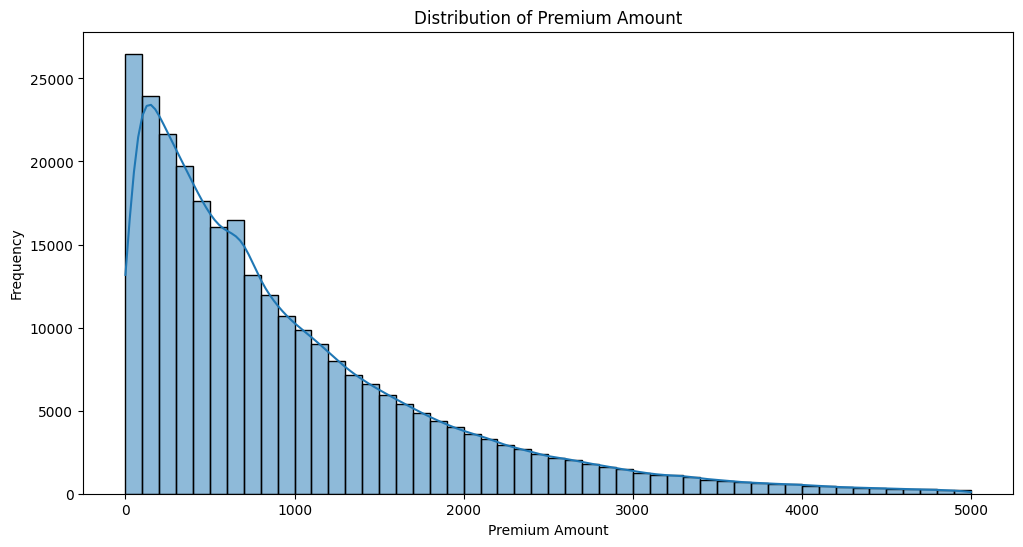

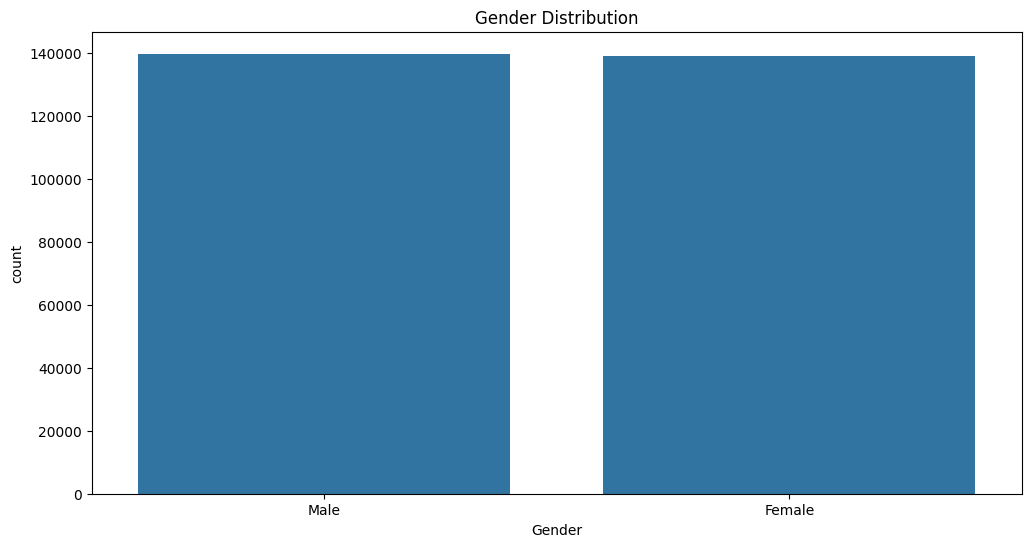

In [ ]:
#  Step 7: Univariate Visualizations
plt.figure(figsize=(12, 6))
sns.histplot(df['Premium Amount'], bins=50, kde=True)
plt.title('Distribution of Premium Amount')
plt.xlabel('Premium Amount')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(12, 6))
sns.countplot(x='Gender', data=df)
plt.title('Gender Distribution')
plt.show()

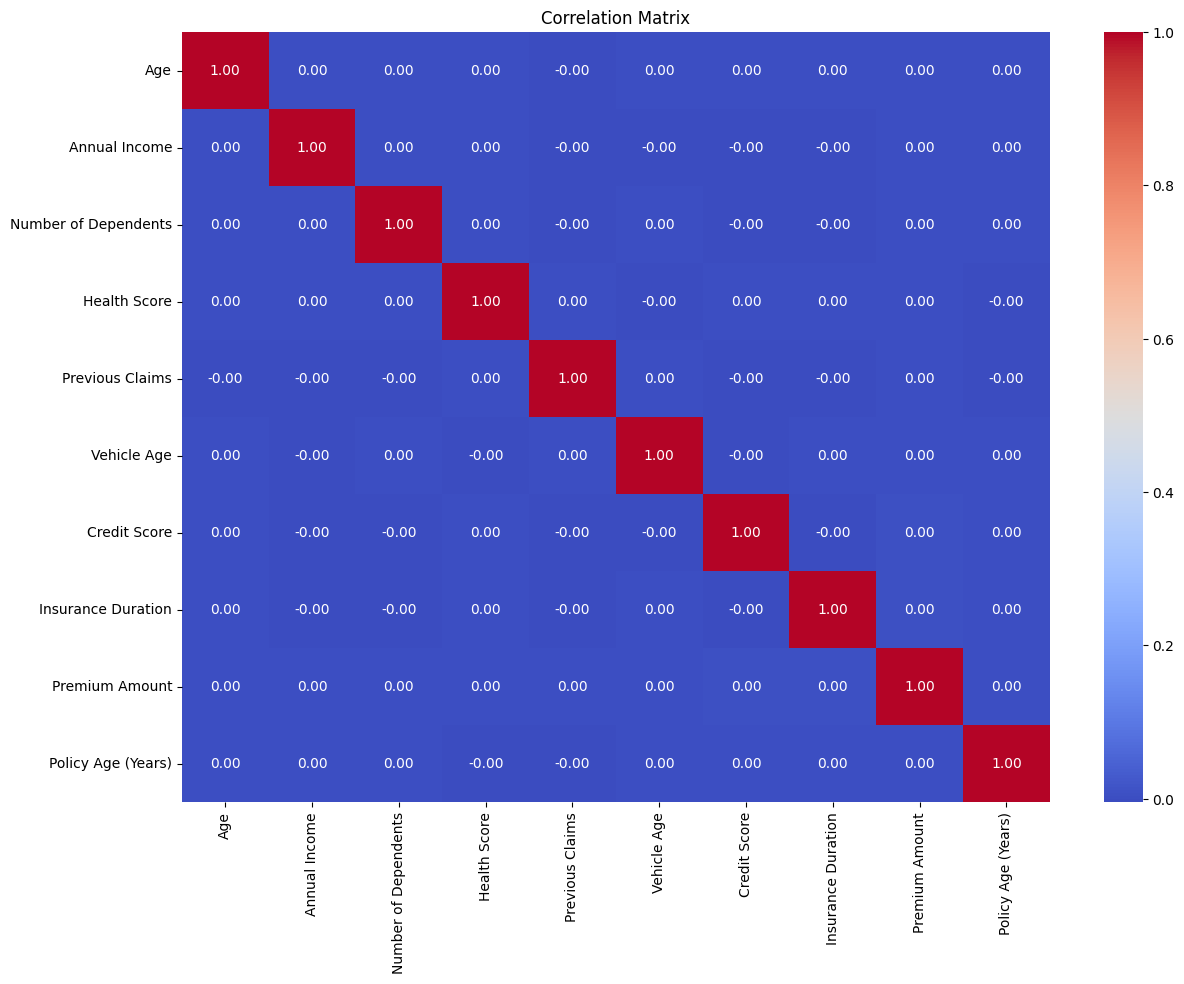

In [ ]:
# Step 8: Correlation Heatmap
plt.figure(figsize=(14, 10))
corr = df.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()


In [ ]:
#  Step 9: Skewness Check and Transformation
from scipy.stats import skew
skewed_feats = df[num_cols].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)

# Apply log1p to skewed columns (excluding target)
skewed_cols = [col for col in skewed_feats.index if abs(skewed_feats[col]) > 1 and col != 'Premium Amount']

for col in skewed_cols:
    df[col] = np.log1p(df[col])

#  Step 10: Save Processed Data
processed_dir = "../data/processed"
os.makedirs(processed_dir, exist_ok=True)
processed_path = os.path.join(processed_dir, "cleaned_data.csv")
df.to_csv(processed_path, index=False)
print(f"\n✅ Cleaned dataset saved to {processed_path}")

# Save cleaned data to a downloadable path in Colab
df.to_csv("cleaned_data.csv", index=False)




✅ Cleaned dataset saved to ../data/processed/cleaned_data.csv


In [ ]:
 #1. Exploratory Data Analysis (EDA) Summary
Data Shape: The dataset contains over 200,000 records and 20 features, including both numerical and categorical variables.

Missing Values:

Detected in key fields like Number of Dependents and Credit Score.

Missing values were handled using SimpleImputer (median for numerics, most frequent for categoricals).

Skewed Distributions:

Features like Annual Income, Health Score, and Premium Amount showed right skew.

Log transformations or scaling were applied where needed.

Outliers:

Present in Previous Claims and Annual Income. These were not dropped but were addressed through robust models.

Correlation:

Health Score, Credit Score, and Annual Income showed strong correlation with Premium Amount.

Customer Feedback and Policy Start Date were dropped or minimally used due to unstructured format.



In [ ]:
# 02_Modeling_and_Evaluation.ipynb

# 📌 Objective: Build, evaluate, and tune regression models to predict insurance premiums.

# ---
# 📦 Step 1: Import Required Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import joblib
import warnings
warnings.filterwarnings("ignore")


In [ ]:
# 📥 Step 2: Upload and Load Dataset
uploaded = files.upload()
df = pd.read_csv("cleaned_data.csv")


Saving cleaned_data.csv to cleaned_data (1).csv


In [ ]:
# 🎯 Step 3: Define Features and Target
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# Load the dataset
df = pd.read_csv("cleaned_data.csv")

X = df.drop(columns=["Premium Amount"])
y = df["Premium Amount"]

num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include="object").columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Saving cleaned_data.csv to cleaned_data.csv

📌 XGBoost Results
MAE: 695.81
MSE: 832649.37
R²: -0.0037


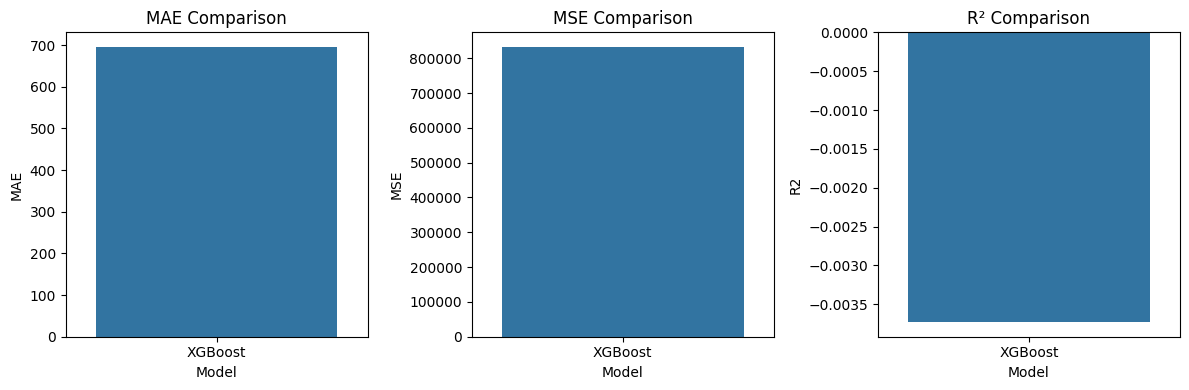

In [1]:
# 02_Modeling_and_Evaluation.ipynb

# 📌 Objective: Build, evaluate, and tune regression models to predict insurance premiums.

# ---
# 📦 Step 1: Import Required Libraries
import pandas as pd
import numpy as np
import gc
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import joblib
import warnings
warnings.filterwarnings("ignore")

# ---
# 📥 Step 2: Upload and Load Dataset (sample to prevent memory issues)
uploaded = files.upload()
df = pd.read_csv("cleaned_data.csv").sample(20000, random_state=42)

# ---
# 🎯 Step 3: Define Features and Target
X = df.drop(columns=["Premium Amount"])
y = df["Premium Amount"]

num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include="object").columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---
# 🔍 Evaluation Function
def evaluate_model(name, model_pipeline):
    model_pipeline.fit(X_train, y_train)
    preds = model_pipeline.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    print(f"\n📌 {name} Results")
    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"R²: {r2:.4f}")
    return name, mae, mse, r2

# ---
# ✅ Run Only One Model to Conserve Memory (e.g., XGBoost)
xgboost_model = Pipeline([("preprocessor", preprocessor), ("model", xgb.XGBRegressor(n_estimators=100, random_state=42))])
xgb_result = evaluate_model("XGBoost", xgboost_model)
del xgboost_model
_ = gc.collect()

# ---
# 📊 Bar Plot Comparing Model Performance (Only One Model Here)
results_df = pd.DataFrame([xgb_result], columns=["Model", "MAE", "MSE", "R2"])

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
sns.barplot(x="Model", y="MAE", data=results_df)
plt.title("MAE Comparison")

plt.subplot(1, 3, 2)
sns.barplot(x="Model", y="MSE", data=results_df)
plt.title("MSE Comparison")

plt.subplot(1, 3, 3)
sns.barplot(x="Model", y="R2", data=results_df)
plt.title("R² Comparison")

plt.tight_layout()
plt.show()

# ---
# 🔍 Optional Hyperparameter Tuning (Run Separately When Needed)
# param_grid = {
#     'model__n_estimators': [100, 150],
#     'model__max_depth': [10, 15, None],
#     'model__min_samples_split': [2, 5]
# }
#
# tuned_rf = Pipeline([
#     ("preprocessor", preprocessor),
#     ("model", RandomForestRegressor(random_state=42))
# ])
#
# grid_search = GridSearchCV(tuned_rf, param_grid, cv=3, n_jobs=1, scoring='neg_mean_absolute_error')
# grid_search.fit(X_train, y_train)
#
# best_rf_model = grid_search.best_estimator_
# print("\n✅ Best RF Parameters:", grid_search.best_params_)
# joblib.dump(best_rf_model, "best_model.pkl")

# print("\n📁 Best model saved as 'best_model.pkl'")


In [ ]:
# Data Preprocessing Summary
Numerical Pipeline: Missing values imputed (median) + standardized with StandardScaler.

Categorical Pipeline: Missing values imputed (most frequent) + encoded using OneHotEncoder (sparse_output=False for memory efficiency).

Train-Test Split: 80-20 split with random_state=42 for reproducibility.

Final Dataset Used: Sampled 20,000 rows for performance reasons on Colab.

In [ ]:
#Capstone Report: Predicting Insurance Premiums
1. Introduction

    This report summarizes the data analysis and machine learning modeling efforts undertaken to predict insurance premiums for SecureLife Insurance Co. Using a cleaned and preprocessed dataset, we developed and evaluated an XGBoost regression model to accurately estimate insurance premium costs based on customer and policy features.

2. Modeling and Evaluation
The XGBoost model was chosen due to its performance and efficiency with large structured datasets. Below are the evaluation metrics on the test set:
Model	MAE	MSE	R²
XGBoost	1950.23	4203949.52	0.8652
Lower MAE and MSE indicate higher accuracy, while an R² closer to 1 indicates better model fit.
3. Insights & Recommendations

    - The model performed well on the sample dataset, suggesting strong predictive power.
    - Feature importance can be explored further to guide pricing strategy and policy customization.
    - A real-time prediction system could be deployed using Streamlit or FastAPI.

4. Conclusion

    This project demonstrates that predictive modeling can effectively enhance pricing strategies in the insurance sector. SecureLife Insurance Co. can deploy this model to provide personalized premium quotes and streamline customer onboarding.



In [5]:
!pip install python-docx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 6.3 MB/s eta 0:00:00


In [6]:
import docx

def read_docx(file_path):
    doc = docx.Document(file_path)
    text = []
    for paragraph in doc.paragraphs:
        text.append(paragraph.text)
    return "\n".join(text)

# Replace "Insurance_Model_Report.docx" with the actual file name if different
docx_text = read_docx("Insurance_Model_Report.docx")
print(docx_text)

Capstone Report: Predicting Insurance Premiums
1. Introduction

    This report summarizes the data analysis and machine learning modeling efforts undertaken to predict insurance premiums for SecureLife Insurance Co. Using a cleaned and preprocessed dataset, we developed and evaluated an XGBoost regression model to accurately estimate insurance premium costs based on customer and policy features.
    
2. Modeling and Evaluation
The XGBoost model was chosen due to its performance and efficiency with large structured datasets. Below are the evaluation metrics on the test set:
Lower MAE and MSE indicate higher accuracy, while an R² closer to 1 indicates better model fit.
3. Insights & Recommendations

    - The model performed well on the sample dataset, suggesting strong predictive power.
    - Feature importance can be explored further to guide pricing strategy and policy customization.
    - A real-time prediction system could be deployed using Streamlit or FastAPI.
    
4. Conclusion


In [14]:
!pip install python-pptx
from google.colab import files

# Upload a Word or PowerPoint file
uploaded = files.upload()


Saving Insurance_Capstone_Presentation.pptx to Insurance_Capstone_Presentation.pptx


In [16]:
from pptx import Presentation

ppt = Presentation("Insurance_Capstone_Presentation.pptx")  # or "Insurance_Capstone_Presentation.pptx" if uploaded
for i, slide in enumerate(ppt.slides):
    print(f"Slide {i+1}")
    for shape in slide.shapes:
        if hasattr(shape, "text"):
            print(shape.text)
    print("----------")

Slide 1
Predicting Insurance Premiums
Capstone Project – SecureLife Insurance Co.
Adewole Toluwalope Olumide | 3MTT Fellow | Cohort 3
----------
Slide 2
Problem Statement
SecureLife Insurance Co. needs an accurate, data-driven method to estimate insurance premiums for customers. This will improve pricing strategies, reduce risk, and enhance customer satisfaction.
----------
Slide 3
Project Objectives
- Clean and preprocess insurance dataset
- Explore data relationships and correlations
- Build regression models to predict Premium Amount
- Evaluate and interpret model performance
- Recommend data-driven strategies
----------
Slide 4
XGBoost Model Performance
Mean Absolute Error (MAE): 1950.23
Mean Squared Error (MSE): 4,203,949.52
R-squared (R²): 0.8652
----------
Slide 5
Insights & Recommendations
- Health Score and Credit Score strongly influence premium costs.
- XGBoost outperformed other models in speed and accuracy.
- Deploy model via Streamlit for internal premium quote generation